# 7CS033 Workshop 4 Exercises

Complete all the exercises.

First, try to solve the questions independently, and then review the solutions. If you are struggling with a question, try using independant research to look for useful functions to help solve the problem. Ensure you understand the given solution to each problem before moving on to the next.

We are using the titanic.csv data which can be found on Canvas.

## Importing necessary Libraries  

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

##### Q1: Write code to load the cancer.csv dataset into a dataframe. Display the first five rows of the dataset. Determine the shape of the dataset and basic information about each column. Identify the target variable and input variables, seperate them into two X, the input features, and y, the target.

In [2]:
#Solution

df = pd.read_csv('cancer.csv')

print(df.head()) # shape of the dataset
print(df.shape)
print(df.info()) # basic information about each column

#target variable is the Diagnosis feature

X = df.drop(columns = ['Diagnosis']) #input variables
y = df['Diagnosis'] #target variable

   radius1  texture1  perimeter1   area1  smoothness1  compactness1  \
0    17.99     10.38      122.80  1001.0      0.11840       0.27760   
1    20.57     17.77      132.90  1326.0      0.08474       0.07864   
2    19.69     21.25      130.00  1203.0      0.10960       0.15990   
3    11.42     20.38       77.58   386.1      0.14250       0.28390   
4    20.29     14.34      135.10  1297.0      0.10030       0.13280   

   concavity1  concave_points1  symmetry1  fractal_dimension1  ...  texture3  \
0      0.3001          0.14710     0.2419             0.07871  ...     17.33   
1      0.0869          0.07017     0.1812             0.05667  ...     23.41   
2      0.1974          0.12790     0.2069             0.05999  ...     25.53   
3      0.2414          0.10520     0.2597             0.09744  ...     26.50   
4      0.1980          0.10430     0.1809             0.05883  ...     16.67   

   perimeter3   area3  smoothness3  compactness3  concavity3  concave_points3  \
0      184.

##### Q2: Write code to appropriatley scale the features of X. Briefly discuss why this process is important for clustering.

In [4]:
#Solution

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X) #scale the features of X

print(X)

####Briefly discuss why this process is important for clustering#####

#Scaling is important for clustering as distance is used to determine the clusters. If the features are not transformed 
#to be on the same scale then patterns in the data could be hidden by certain features dominating due to their different
#scale. Standardising all of the data ensures that each feature will fairly contribute to the clustering process.

[[ 1.09706398 -2.07333501  1.26993369 ...  2.29607613  2.75062224
   1.93701461]
 [ 1.82982061 -0.35363241  1.68595471 ...  1.0870843  -0.24388967
   0.28118999]
 [ 1.57988811  0.45618695  1.56650313 ...  1.95500035  1.152255
   0.20139121]
 ...
 [ 0.70228425  2.0455738   0.67267578 ...  0.41406869 -1.10454895
  -0.31840916]
 [ 1.83834103  2.33645719  1.98252415 ...  2.28998549  1.91908301
   2.21963528]
 [-1.80840125  1.22179204 -1.81438851 ... -1.74506282 -0.04813821
  -0.75120669]]


##### Q3: Write code to fit K-means clustering models for values of k = 1 to k = 10. Plot the elbow curve for these models and use this plot to determine an appropriate number of clusters. Determine the silhouette score for these models and compare the result to the elbow curve. Finally, fit K-means using your chosen k.

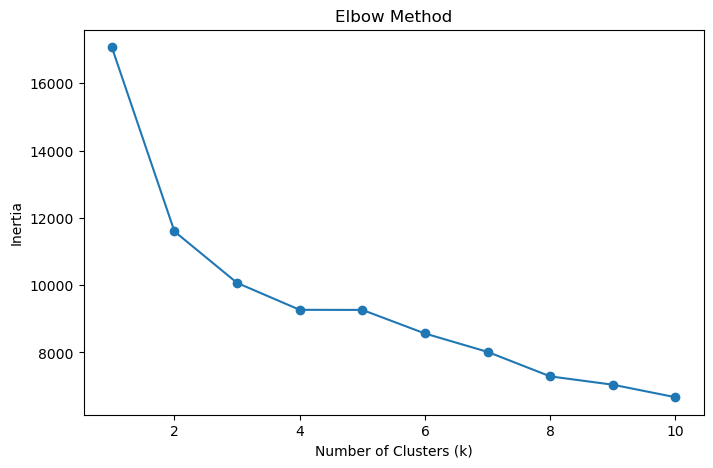

In [5]:
#Solution
from sklearn.cluster import KMeans

#Since we will need to plot the elbow curve we will create an empty list to store the inertia values
inertia = []

#Write code to fit K-means clustering models for values of k = 1 to k = 10
#Fit our model for the appropriate range of k and store the inertia values for later use
for k in range(1, 11):
    km = KMeans(n_clusters = k, random_state = 42)
    km.fit(X)
    inertia.append(km.inertia_)

#plot the elbow curve
plt.figure(figsize=(8,5))
plt.plot(range(1,11), inertia, marker = 'o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

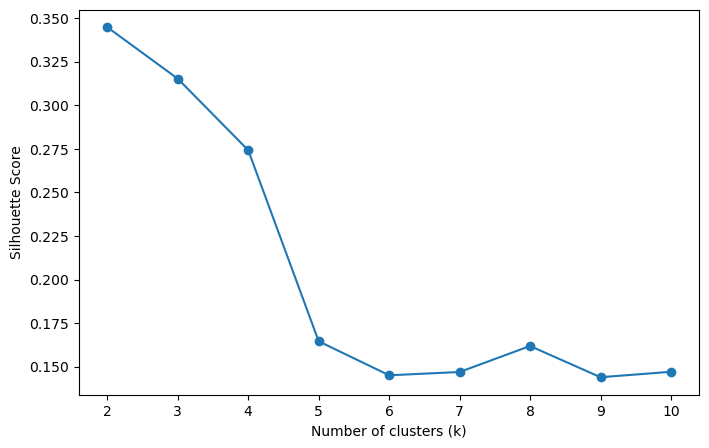

In [7]:
#Based off of the plot we could argue that k = 2, k = 3 or k = 4 are appropriate, let us check with silhouette scores.

from sklearn.metrics import silhouette_score

sil_scores = []

#
for k in range (2, 11):
    km = KMeans(n_clusters = k, random_state = 42)
    labels = km.fit_predict(X)
    sil_scores.append(silhouette_score(X, labels))

plt.figure(figsize = (8, 5))
plt.plot(range(2,11), sil_scores, marker = 'o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.show

In [9]:
#based off of both the elbow method and the silhouette scores we shall use k = 2. This matches what we know from the data itself.

kmeans = KMeans(n_clusters = 2, random_state = 42)
kmeans_predic = kmeans.fit_predict(X)

##### Q4: Explain why K-Means could struggle if the clusters in the data are not spherical?

###### Solution:

K-means creates clusters using distance. Points are considered similar if they are close together in the feature space. By definition, this method assumes that clusters must be spherical and of different sizes. If the clusters were a different shape such as curved or elongated, then K-means could potentially merge or split clusters incorrectly.

##### Q5: Write code to fit agglomerative hierarchical clustering for the same k as chosen previously. Compute the silhouette score for this and then compare the score to K-Means. Which method appears to perform better?

In [12]:
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters = 2)
agg_predic = agg.fit_predict(X)

sil_agg = silhouette_score(X, agg_predic)
print('Agglomerative Silhouette Score: ', sil_agg)

Agglomerative Silhouette Score:  0.33938477753669855


In [13]:
#Since both scores seem similar and it is hard to read the exact value for K-means from the graph lets look at the actual value

sil_km = silhouette_score(X, kmeans_predic)
print('K-Means Silhouette Score: ', sil_km)

K-Means Silhouette Score:  0.3447344346611054


K-Means performed slightly better according to the silhouette scores. K-Means = 0.345, Agglomerative = 0.339.

##### Q6: Why would we not use the elbow method for hierarchical clustering?

###### Solution:

The elbow method uses the interia, which is the sum of squares of the distance of each point to its cluster centroid. This is specific to K-means and would make no sense to use on hierarchical algorithms as they do not optimise inertia. A more suitable visualisation would be a dendrogram.

##### Q7: Write code to apply PCA to reduce the data to two principal components. Create three scatter plots: PCA coloured by K-Means clusters, PCA coloured by Agglomerative clusters and PCA coloured by the target labels. What differences do you observe?

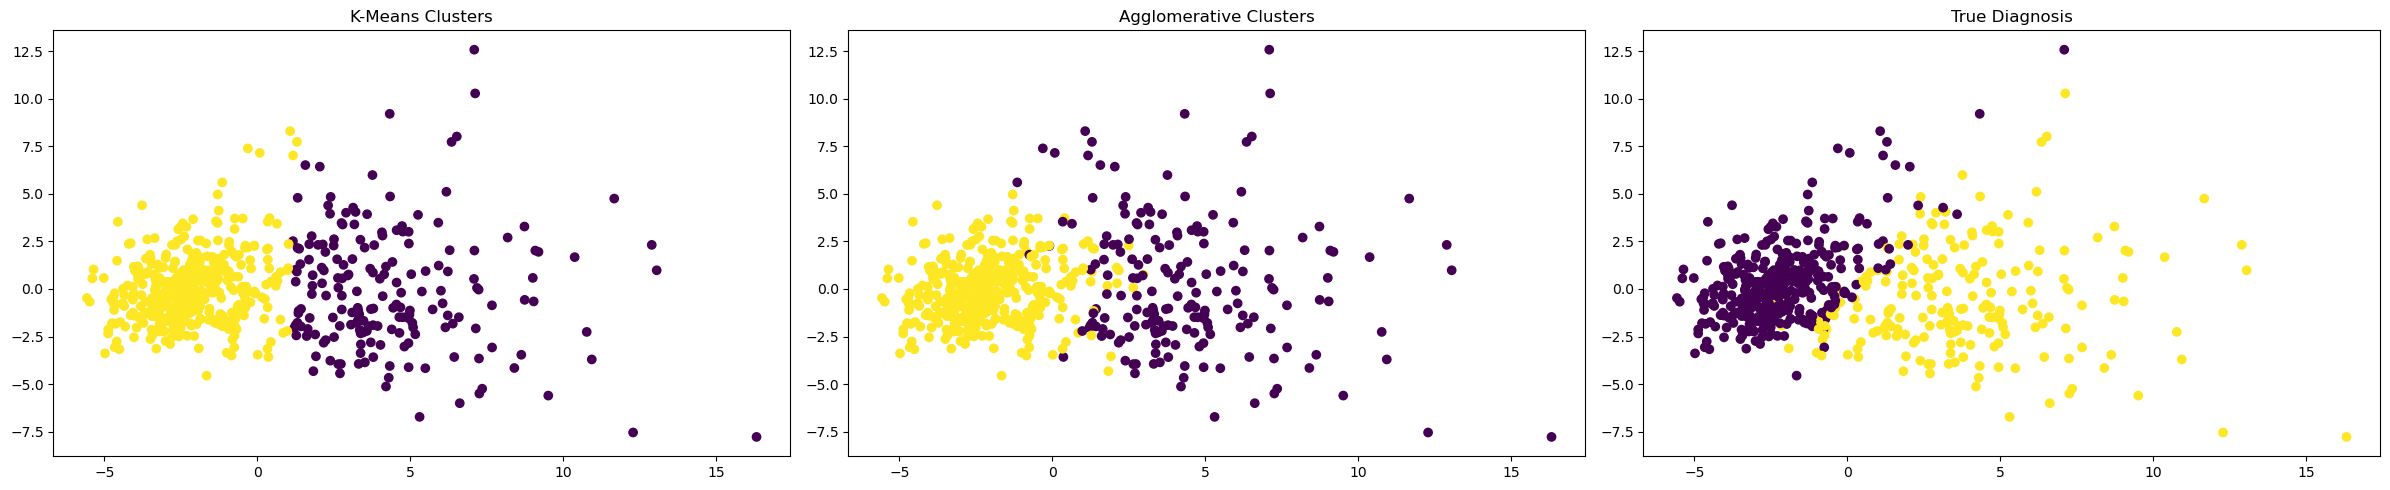

In [14]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

#apply PCA to the features
pca = PCA(n_components = 2)
X_pca = pca.fit_transform(X)

#create the scatterplots 
fig, axes = plt.subplots(1, 3, figsize = (24, 5))

axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c = kmeans_predic)
axes[0].set_title('K-Means Clusters')

axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c = agg_predic)
axes[1].set_title('Agglomerative Clusters')

axes[2].scatter(X_pca[:, 0], X_pca[:, 1], c = y_encoded)
axes[2].set_title('True Diagnosis')

plt.tight_layout()
plt.show()


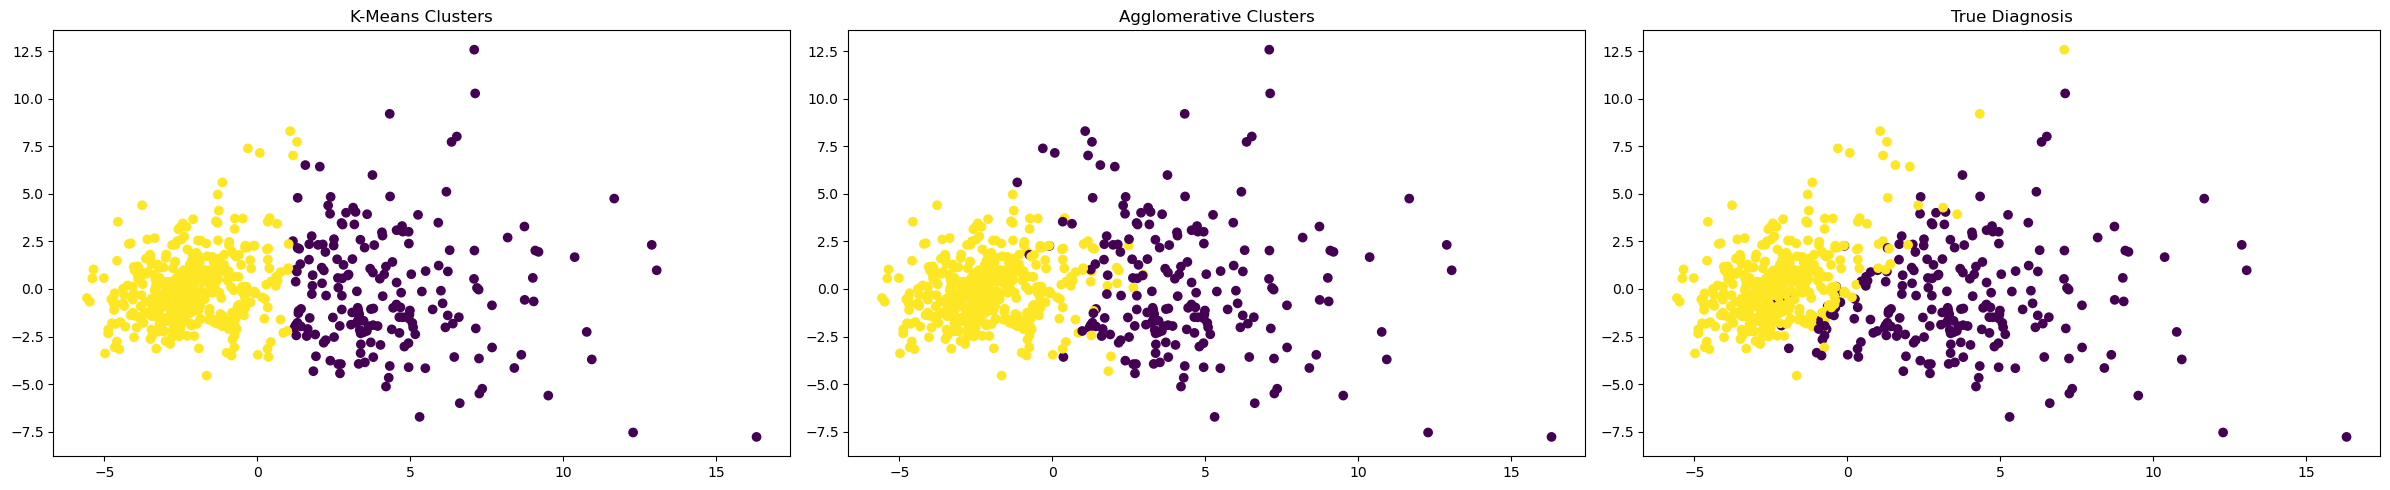

In [15]:
#one thing that would be preferable would be that the colours for the clusters and the true diagnosis were more closely alighned for ease of assessment. To change this we
#manually encode the labels for y to make things look nicer

y_encoded2 = y.map({'B': 1, 'M': 0})

#apply PCA to the features
pca = PCA(n_components = 2)
X_pca = pca.fit_transform(X)

#create the scatterplots 
fig, axes = plt.subplots(1, 3, figsize = (24, 5))

axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c = kmeans_predic)
axes[0].set_title('K-Means Clusters')

axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c = agg_predic)
axes[1].set_title('Agglomerative Clusters')

axes[2].scatter(X_pca[:, 0], X_pca[:, 1], c = y_encoded2)
axes[2].set_title('True Diagnosis')

plt.tight_layout()
plt.show()

##### Q8: Write code to determine the accuracy of the clustering of both algorithms.

In [16]:
#Solution

from sklearn.metrics import accuracy_score

kmeans_accuracy = accuracy_score(y_encoded2, kmeans_predic)
agg_accuracy = accuracy_score(y_encoded2, agg_predic)

print('K-Means Accuracy: %.2f' %kmeans_accuracy)
print('Agglomerative Accuracy: %.2f' %agg_accuracy)

#Note: Remember for this to work the labels of our clusters must align with the target labels

K-Means Accuracy: 0.91
Agglomerative Accuracy: 0.88


##### Q9: What happens if we do not scale the data before applying clustering? Does this impact the results?

In [17]:
#Solution

X_unscaled = df.drop(columns = ['Diagnosis'])

kmeans_unscaled = KMeans(n_clusters = 2, random_state = 42)
unscaled_predic = kmeans.fit_predict(X_unscaled)
sil_unscaled = silhouette_score(X_unscaled, unscaled_predic)

print('Silhouette score for unscaled data: %.2f' %sil_unscaled)

Silhouette score for unscaled data: 0.70


At first glance this may seem like that by not scaling our data we have much more successful clustering. However, since silhouette score is based on distance and our unscaled data has features with larger magnitudes, what can happen is our algorithm ends up focusing on these larger features and ignoring smaller scale features. This can make the data look more clearly seperated but does not necessarily mean our new clusters are accuractely representing patterns in the data. Lets compere the accuracy of our new model.

In [18]:
unscaled_accuracy = accuracy_score(y_encoded2, unscaled_predic)

print('Unscaled K-Means Accuracy: %.2f' %unscaled_accuracy)

Unscaled K-Means Accuracy: 0.85


We can see that our clusters were worse when applying the algorithm to our unscaled data. For this dataset the features ranges are failry similar, with a few features such as perimeter1 and area1 being much larger than the other features.

###### What happens if you perform clustering on the PCA transformed data? 